# Custom Reaction Networks in Monod

This notebook demonstrates the new `ReactionNetwork` module, which lets you define
arbitrary biological noise models via a reaction-string syntax and have the required
CME log-PGF equations derived automatically.

## Syntax at a glance

```
"0 -> B x U -> S -> 0"
```

* Reactions are separated by **`->`** (chain) or **`;`** (independent).
* `0` is the empty set (source / sink).
* `B x U` — capital-letter prefix → **geometric burst** of mean B.
* `2 x U` — integer prefix → **deterministic burst** of size 2.
* `A + B` — multi-species nodes (products or reactants).

Parameters are ordered: **named burst-size params first, then one rate per `→`**,
all in log₁₀ scale (matching the rest of monod).

## Contents

1. Parsing and introspection  
2. Recovering the built-in **Bursty** model  
3. Adding a secondary degradation pathway (`; U -> 0`)  
4. Catalytic protein production (`S -> S + P`)  
5. Constitutive model from scratch  
6. Burst-size sweep  
7. Model selection: which network best fits real data?

In [1]:
import sys, os
sys.path.insert(0, os.path.join('src', 'monod'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from reaction_network import ReactionNetwork
from cme_toolbox import CMEModel

In [2]:
# ── Shared plotting helper ───────────────────────────────────────────────────

def plot_joint(pss, title, xlabel='Species 0', ylabel='Species 1', cmap='Blues'):
    """Joint PMF heatmap with marginal line plots."""
    fig = plt.figure(figsize=(6, 5))
    gs  = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                           hspace=0.05, wspace=0.05)
    ax_j = fig.add_subplot(gs[1, 0])
    ax_t = fig.add_subplot(gs[0, 0], sharex=ax_j)
    ax_r = fig.add_subplot(gs[1, 1], sharey=ax_j)

    im = ax_j.imshow(pss.T, origin='lower', aspect='auto', cmap=cmap,
                     norm=mcolors.PowerNorm(gamma=0.4, vmin=0))
    ax_j.set_xlabel(xlabel, fontsize=11)
    ax_j.set_ylabel(ylabel, fontsize=11)

    m0 = pss.sum(axis=1); m1 = pss.sum(axis=0)
    ax_t.plot(m0, color='steelblue', lw=1.5)
    ax_t.fill_between(range(len(m0)), m0, alpha=0.3, color='steelblue')
    ax_t.set_ylabel('P(0)', fontsize=9)
    ax_r.plot(m1, range(len(m1)), color='salmon', lw=1.5)
    ax_r.fill_betweenx(range(len(m1)), m1, alpha=0.3, color='salmon')
    ax_r.set_xlabel('P(1)', fontsize=9)

    plt.setp(ax_t.get_xticklabels(), visible=False)
    plt.setp(ax_r.get_yticklabels(), visible=False)
    fig.suptitle(title, fontsize=11, y=1.01)
    plt.colorbar(im, ax=[ax_j, ax_r], label='Probability', shrink=0.8)
    plt.tight_layout()
    plt.show()


def marginals(pss):
    """Return (m0, m1) marginal arrays."""
    return pss.sum(axis=1), pss.sum(axis=0)


def mean_counts(pss):
    """Return (E[n0], E[n1])."""
    idx0 = np.arange(pss.shape[0])
    idx1 = np.arange(pss.shape[1])
    return (pss * idx0[:, None]).sum(), (pss * idx1[None, :]).sum()

---
## 1 · Parsing and introspection

Instantiating a `ReactionNetwork` parses the string and extracts:
* **species** — in order of first appearance.
* **named_params** — geometric burst-size parameters.
* **rate_names** — one rate constant per `→`.
* **all_params** — the full parameter vector (log₁₀ scale).

In [3]:
networks = {
    'Bursty equivalent'          : '0 -> B x U -> S -> 0',
    'Bursty + U degradation'     : '0 -> B x U -> S -> 0; U -> 0',
    'Constitutive equivalent'    : '0 -> U -> S -> 0',
    'Deterministic burst of 3'   : '0 -> 3 x U -> S -> 0',
    'Catalytic protein model'    : '0 -> B x U -> S -> S + P; P -> 0',
}

for label, net_str in networks.items():
    net = ReactionNetwork(net_str)
    print(f'{label}')
    print(f'  network    : {net_str}')
    print(f'  species    : {net.species}')
    print(f'  all_params : {net.all_params}')
    print()

Bursty equivalent
  network    : 0 -> B x U -> S -> 0
  species    : ['U', 'S']
  all_params : ['B', 'k0', 'k1', 'k2']

Bursty + U degradation
  network    : 0 -> B x U -> S -> 0; U -> 0
  species    : ['U', 'S']
  all_params : ['B', 'k0', 'k1', 'k2', 'k3']

Constitutive equivalent
  network    : 0 -> U -> S -> 0
  species    : ['U', 'S']
  all_params : ['k0', 'k1', 'k2']

Deterministic burst of 3
  network    : 0 -> 3 x U -> S -> 0
  species    : ['U', 'S']
  all_params : ['k0', 'k1', 'k2']

Catalytic protein model
  network    : 0 -> B x U -> S -> S + P; P -> 0
  species    : ['U', 'S', 'P']
  all_params : ['B', 'k0', 'k1', 'k2', 'k3']



The `repr` of a `ReactionNetwork` shows the parsed reaction list with clear notation:

In [4]:
print(ReactionNetwork('0 -> B x U -> S -> S + P; P -> 0'))

ReactionNetwork('0 -> B x U -> S -> S + P; P -> 0')
  species    : ['U', 'S', 'P']
  all_params : ['B', 'k0', 'k1', 'k2', 'k3']
  reactions  :
    ∅ →(k0) U  [geometric B]
    U →(k1) S
    S →(k2) S + P
    P →(k3) ∅


---
## 2 · Recovering the built-in Bursty model

The string `"0 -> B x U -> S -> 0"` encodes three reactions:

| Reaction | Rate | PGF contribution |
|----------|------|------------------|
| $\emptyset \to \text{Geo}(B)\times U$ | $k_0$ | $d\phi/dt \mathrel{+}= k_0 B u_U / (1 - B u_U)$ |
| $U \to S$ | $k_1$ | $du_U/dt \mathrel{+}= k_1(u_S - u_U)$ |
| $S \to \emptyset$ | $k_2$ | $du_S/dt \mathrel{+}= -k_2 u_S$ |

Setting `normalize_production_rate=True` fixes $k_0 = 1$, making the parameter
vector $[B, k_1, k_2]$ identical to the built-in Bursty model $[b, \beta, \gamma]$.

In [5]:
B, beta, gamma = 3.0, 0.4, 0.25
LIMITS = [60, 80]

# ── Built-in Bursty ──────────────────────────────────────────────────────────
m_builtin = CMEModel('Bursty', 'None')
pss_ref   = m_builtin.eval_model_pss(np.log10([B, beta, gamma]), LIMITS)

# ── Custom equivalent (normalize_production_rate=True drops k0 from params) ─
m_custom = CMEModel(
    'Custom', 'None',
    network='0 -> B x U -> S -> 0',
    normalize_production_rate=True,
    min_fudge=0.05, max_fudge=15,
)
print('Custom param vector:', m_custom.network.all_params)   # [B, k1, k2]
pss_custom = m_custom.eval_model_pss(np.log10([B, beta, gamma]), LIMITS)

# ── Quantitative comparison ──────────────────────────────────────────────────
mask   = pss_ref > 0
kld    = np.sum(pss_ref[mask] * np.log(pss_ref[mask] / np.clip(pss_custom[mask], 1e-15, None)))
eu_ref,  es_ref  = mean_counts(pss_ref)
eu_cust, es_cust = mean_counts(pss_custom)

print(f'\nKL(Bursty ∥ Custom) = {kld:.4f}  (< 0.01 is excellent)')
print(f'E[U]  Bursty={eu_ref:.3f}  Custom={eu_cust:.3f}')
print(f'E[S]  Bursty={es_ref:.3f}  Custom={es_cust:.3f}')

The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
The expected modalities for this model are: ['U', 'S']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
Custom param vector: ['B', 'k1', 'k2']



KL(Bursty ∥ Custom) = 0.0000  (< 0.01 is excellent)
E[U]  Bursty=7.500  Custom=7.525
E[S]  Bursty=12.000  Custom=12.000


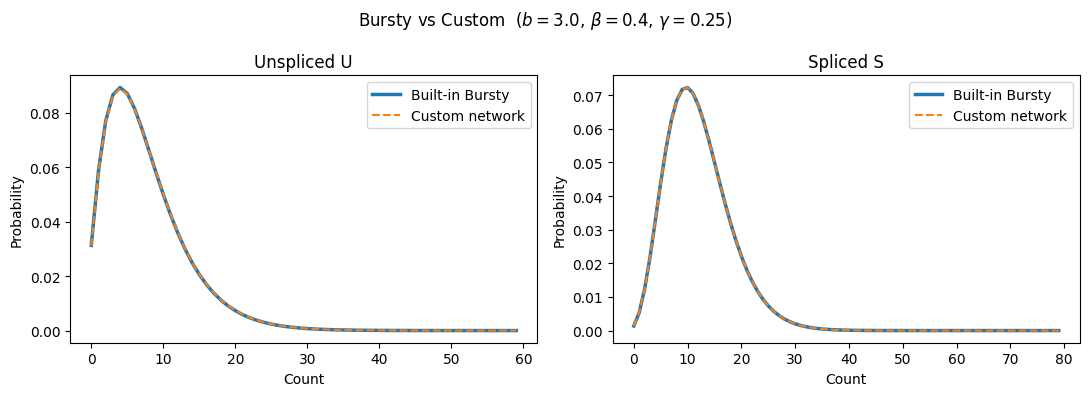

In [6]:
# Side-by-side marginal comparison
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
m0_ref,  m1_ref  = marginals(pss_ref)
m0_cust, m1_cust = marginals(pss_custom)

for ax, m_ref, m_cust, label in [
    (axes[0], m0_ref, m0_cust, 'Unspliced U'),
    (axes[1], m1_ref, m1_cust, 'Spliced S'),
]:
    ax.plot(m_ref,  lw=2.5, label='Built-in Bursty')
    ax.plot(m_cust, lw=1.5, ls='--', label='Custom network')
    ax.set_xlabel('Count'); ax.set_ylabel('Probability')
    ax.set_title(label); ax.legend()

fig.suptitle(
    rf'Bursty vs Custom  ($b={B},\,\beta={beta},\,\gamma={gamma}$)',
    fontsize=12
)
plt.tight_layout(); plt.show()

The two marginals are essentially indistinguishable — the Custom model correctly
recovers the built-in implementation.

---
## 3 · Adding a secondary degradation pathway

The semicolon syntax appends an independent reaction to the network.

```python
"0 -> B x U -> S -> 0; U -> 0"
```

adds $U \to \emptyset$ at rate $k_3$, giving unspliced mRNA **two exit routes**
(splicing at rate $k_1$ _or_ direct degradation at rate $k_3$).
This raises the effective clearance rate of $U$ and reduces $E[U]$ while
leaving $E[S]$ largely unchanged.

In [7]:
net_extra = ReactionNetwork('0 -> B x U -> S -> 0; U -> 0')
print(net_extra)
print('\nall_params:', net_extra.all_params)  # B, k0 (burst rate), k1 (β), k2 (γ), k3 (γ_U)

ReactionNetwork('0 -> B x U -> S -> 0; U -> 0')
  species    : ['U', 'S']
  all_params : ['B', 'k0', 'k1', 'k2', 'k3']
  reactions  :
    ∅ →(k0) U  [geometric B]
    U →(k1) S
    S →(k2) ∅
    U →(k3) ∅

all_params: ['B', 'k0', 'k1', 'k2', 'k3']


The expected modalities for this model are: ['U', 'S']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
The expected modalities for this model are: ['U', 'S']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 


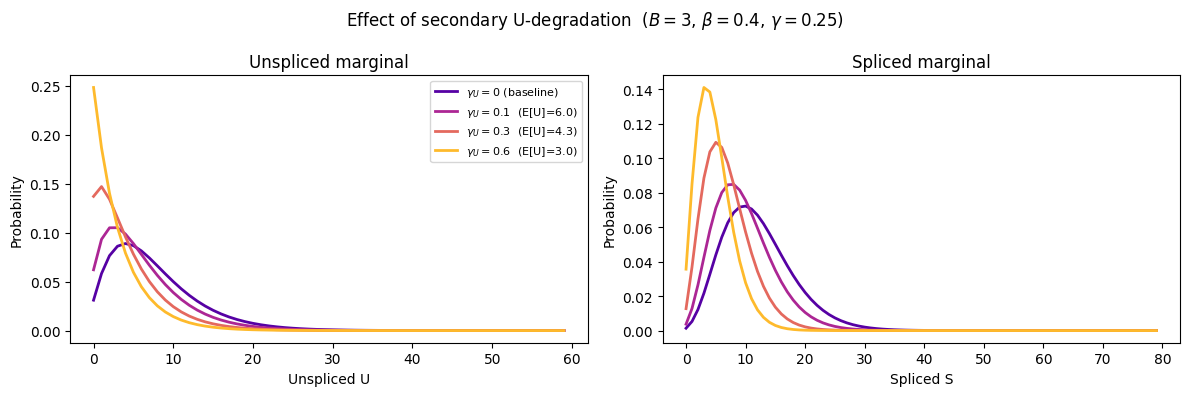

In [8]:
B, beta, gamma = 3.0, 0.4, 0.25
LIMITS = [60, 80]

# Baseline: Bursty without extra degradation (normalize k0=1)
m_base = CMEModel('Custom', 'None',
                  network='0 -> B x U -> S -> 0',
                  normalize_production_rate=True,
                  min_fudge=0.05, max_fudge=15)
pss_base = m_base.eval_model_pss(np.log10([B, beta, gamma]), LIMITS)

# Vary extra U degradation rate gamma_U
gamma_U_vals = [0.0, 0.1, 0.3, 0.6]

m_extra = CMEModel('Custom', 'None',
                   network='0 -> B x U -> S -> 0; U -> 0',
                   normalize_production_rate=True,
                   min_fudge=0.05, max_fudge=15)
# params order: [B, k1=beta, k2=gamma, k3=gamma_U]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(gamma_U_vals)))

for gamma_U, col in zip(gamma_U_vals, colors):
    if gamma_U == 0.0:
        pss = pss_base
        lbl = r'$\gamma_U = 0$ (baseline)'
    else:
        p = np.log10([B, beta, gamma, gamma_U])
        pss = m_extra.eval_model_pss(p, LIMITS)
        eu, es = mean_counts(pss)
        lbl = rf'$\gamma_U = {gamma_U}$  (E[U]={eu:.1f})'

    m0, m1 = marginals(pss)
    eu, es = mean_counts(pss)
    axes[0].plot(m0, color=col, lw=2, label=lbl)
    axes[1].plot(m1, color=col, lw=2)

axes[0].set_xlabel('Unspliced U'); axes[0].set_ylabel('Probability')
axes[0].set_title('Unspliced marginal'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('Spliced S'); axes[1].set_ylabel('Probability')
axes[1].set_title('Spliced marginal')

fig.suptitle(
    r'Effect of secondary U-degradation  ($B=3,\,\beta=0.4,\,\gamma=0.25$)',
    fontsize=12
)
plt.tight_layout(); plt.show()

Adding $U \to \emptyset$ compresses the unspliced distribution toward zero while
leaving the spliced marginal nearly unchanged — exactly the expected phenomenology.

---
## 4 · Catalytic protein production

The reaction `S -> S + P` means spliced mRNA **catalyses** production of protein P
without being consumed.  Its propensity is $k \cdot n_S$ (first-order in $n_S$),
but the characteristic ODE gains a **nonlinear** term:

$$\frac{du_S}{dt} \mathrel{+}= k_2 \, u_P \, (1 + u_S)$$

This is exactly the ProteinBursty model, so we can compare directly:

In [9]:
net_prot = ReactionNetwork('0 -> B x U -> S -> 0; S -> S + P; P -> 0')
print(net_prot)
print('\nall_params:', net_prot.all_params)
# [B, k0 (burst rate), k1 (β), k2 (γ_s), k3 (k_p catalytic), k4 (γ_p)]


ReactionNetwork('0 -> B x U -> S -> 0; S -> S + P; P -> 0')
  species    : ['U', 'S', 'P']
  all_params : ['B', 'k0', 'k1', 'k2', 'k3', 'k4']
  reactions  :
    ∅ →(k0) U  [geometric B]
    U →(k1) S
    S →(k2) ∅
    S →(k3) S + P
    P →(k4) ∅

all_params: ['B', 'k0', 'k1', 'k2', 'k3', 'k4']


In [10]:
# The ProteinBursty-equivalent network:
#   0 -> B x U  (bursty transcription)
#   U -> S       (splicing, rate beta)
#   S -> 0       (mRNA degradation, rate gamma_s)
#   S -> S + P   (catalytic protein production, rate k_p)
#   P -> 0       (protein degradation, rate gamma_p)
#
# Note: the pure-Python RK4 path is used for 3+ species models (no Rust path yet);
# use a small grid to keep runtime short.
NETWORK_PROT = '0 -> B x U -> S -> 0; S -> S + P; P -> 0'
B_p, beta_p, gamma_s, k_p, gamma_p = 2.0, 1.5, 1.0, 1.2, 0.8
LIMITS_3D = [12, 12, 20]

m_prot = CMEModel(
    'Custom', 'None',
    network=NETWORK_PROT,
    normalize_production_rate=True,
    min_fudge=0.05, max_fudge=15,
)
print('Network:', NETWORK_PROT)
print('Custom params:', m_prot.network.all_params)
# [B, k1(beta), k2(gamma_s), k3(k_p), k4(gamma_p)]

p_prot = np.log10([B_p, beta_p, gamma_s, k_p, gamma_p])
pss_3d = m_prot.eval_model_pss(p_prot, LIMITS_3D)
print('PSS shape:', pss_3d.shape, ' (U x S x P)')
print('PSS sum:  ', round(pss_3d.sum(), 6))

The expected modalities for this model are: ['U', 'S', 'P']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
Network: 0 -> B x U -> S -> 0; S -> S + P; P -> 0
Custom params: ['B', 'k1', 'k2', 'k3', 'k4']
PSS shape: (12, 12, 20)  (U x S x P)
PSS sum:   1.0


E[U] = 1.31,  E[S] = 1.97,  E[P] = 2.99


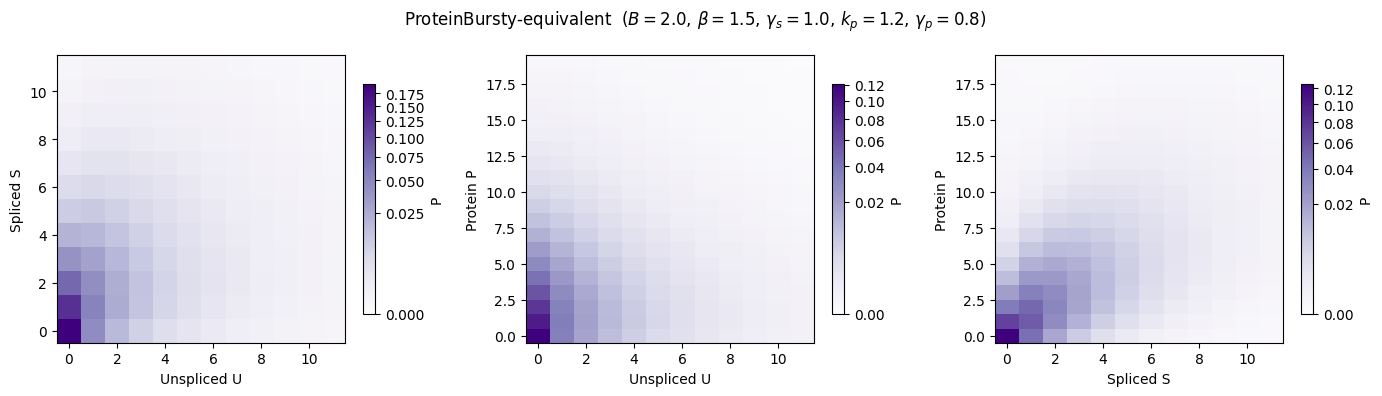

In [11]:
# Marginalise to 2D projections for visualisation
pss_US = pss_3d.sum(axis=2)   # U × S
pss_UP = pss_3d.sum(axis=1)   # U × P
pss_SP = pss_3d.sum(axis=0)   # S × P

eu, es, ep = [
    (pss_3d * np.arange(pss_3d.shape[i])[
        tuple(slice(None) if j == i else np.newaxis for j in range(3))
    ]).sum()
    for i in range(3)
]
print(f'E[U] = {eu:.2f},  E[S] = {es:.2f},  E[P] = {ep:.2f}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, pss2, xl, yl in [
    (axes[0], pss_US, 'Unspliced U', 'Spliced S'),
    (axes[1], pss_UP, 'Unspliced U', 'Protein P'),
    (axes[2], pss_SP, 'Spliced S',   'Protein P'),
]:
    im = ax.imshow(pss2.T, origin='lower', aspect='auto', cmap='Purples',
                   norm=mcolors.PowerNorm(gamma=0.4, vmin=0))
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    plt.colorbar(im, ax=ax, label='P', shrink=0.8)

fig.suptitle(
    rf'ProteinBursty-equivalent  ($B={B_p},\,\beta={beta_p},\,\gamma_s={gamma_s},\,k_p={k_p},\,\gamma_p={gamma_p}$)',
    fontsize=12
)
plt.tight_layout(); plt.show()

---
## 5 · Constitutive model from scratch

`"0 -> U -> S -> 0"` has no burst parameter — production is deterministic
(one molecule at a time), so both marginals are Poisson.

The parameter vector is `[k0, k1, k2]` — three rates, no named burst parameter.

all_params: ['k0', 'k1', 'k2']
The expected modalities for this model are: ['U', 'S']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
E[U] = 2.525  (expected 2.500)
E[S] = 4.000  (expected 4.000)


/var/folders/kj/wm2vrp3x04qgzq18l2rkrcxh0000gn/T/ipykernel_70168/1256064320.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


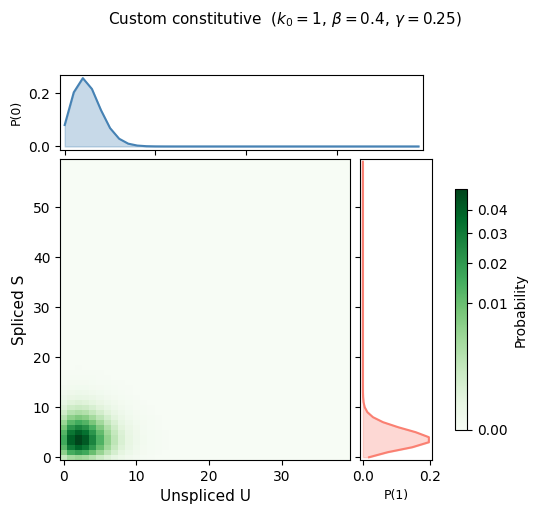

In [12]:
net_const = ReactionNetwork('0 -> U -> S -> 0')
print('all_params:', net_const.all_params)   # [k0, k1, k2]  — no named param

# k0=1 (prod rate), k1=0.4 (β), k2=0.25 (γ)  →  Poisson(mean = k0/k1 = 2.5)
m_const = CMEModel('Custom', 'None', network='0 -> U -> S -> 0',
                   min_fudge=0.05, max_fudge=15)
p_const  = np.log10([1.0, 0.4, 0.25])   # [k0, k1, k2]
pss_const = m_const.eval_model_pss(p_const, [40, 60])

eu_c, es_c = mean_counts(pss_const)
print(f'E[U] = {eu_c:.3f}  (expected {1.0/0.4:.3f})')
print(f'E[S] = {es_c:.3f}  (expected {1.0/0.25:.3f})')

plot_joint(pss_const,
           r'Custom constitutive  ($k_0=1,\,\beta=0.4,\,\gamma=0.25$)',
           xlabel='Unspliced U', ylabel='Spliced S', cmap='Greens')

---
## 6 · Burst-size sweep — geometric vs deterministic

We compare two ways to produce molecules in groups:

* **`B x U`** (capital letter) — burst size **geometrically distributed** with mean $B$.
* **`n x U`** (integer) — burst size **exactly** $n$ (deterministic).

At matched mean burst size, the geometric distribution produces heavier tails.

The expected modalities for this model are: ['U', 'S']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 


The expected modalities for this model are: ['U', 'S']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
The expected modalities for this model are: ['U', 'S']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 


The expected modalities for this model are: ['U', 'S']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
The expected modalities for this model are: ['U', 'S']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 


The expected modalities for this model are: ['U', 'S']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
The expected modalities for this model are: ['U', 'S']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 


The expected modalities for this model are: ['U', 'S']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 


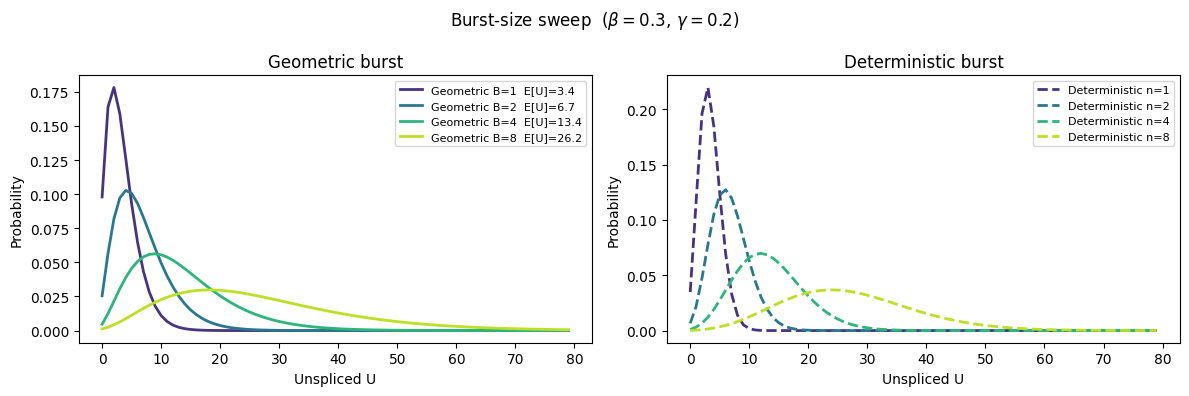

In [13]:
burst_means = [1, 2, 4, 8]
beta_sw, gamma_sw = 0.3, 0.2
LIMITS_SW = [80, 100]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(burst_means)))

for b_mean, col in zip(burst_means, colors):
    # Geometric burst (named B)
    m_geo = CMEModel('Custom', 'None',
                     network='0 -> B x U -> S -> 0',
                     normalize_production_rate=True,
                     min_fudge=0.05, max_fudge=15)
    pss_geo = m_geo.eval_model_pss(np.log10([b_mean, beta_sw, gamma_sw]), LIMITS_SW)

    # Deterministic burst (integer literal)
    n_det = max(1, int(round(b_mean)))
    m_det = CMEModel('Custom', 'None',
                     network=f'0 -> {n_det} x U -> S -> 0',
                     min_fudge=0.05, max_fudge=15)
    # params: [k0, k1, k2]  (no named param)
    pss_det = m_det.eval_model_pss(np.log10([1.0, beta_sw, gamma_sw]), LIMITS_SW)

    eu_g, _ = mean_counts(pss_geo)
    m0_g, _ = marginals(pss_geo)
    m0_d, _ = marginals(pss_det)

    axes[0].plot(m0_g, color=col, lw=2,     label=f'Geometric B={b_mean}  E[U]={eu_g:.1f}')
    axes[1].plot(m0_d, color=col, lw=2, ls='--', label=f'Deterministic n={n_det}')

for ax, title in zip(axes, ['Geometric burst', 'Deterministic burst']):
    ax.set_xlabel('Unspliced U'); ax.set_ylabel('Probability')
    ax.set_title(title); ax.legend(fontsize=8)

fig.suptitle(
    rf'Burst-size sweep  ($\beta={beta_sw},\,\gamma={gamma_sw}$)',
    fontsize=12
)
plt.tight_layout(); plt.show()

Geometric bursts produce broader, heavier-tailed distributions than deterministic
bursts of the same size — a direct consequence of the extra stochasticity in burst size.

---
## 7 · Model selection on real data

We load the bundled example dataset and compare three networks on gene **PTPRC**:

| Model | Network string | Parameters |
|-------|---------------|------------|
| Bursty (built-in) | — | $b, \beta, \gamma$ |
| Bursty + U decay | `0 -> B x U -> S -> 0; U -> 0` | $B, \beta, \gamma, \gamma_U$ |
| Constitutive | `0 -> U -> S -> 0` | $k_0, \beta, \gamma$ |

We fit each by minimising KL-divergence starting from method-of-moments estimates.

In [14]:
import anndata as ad
from extract_data import extract_data, _uns_unpack
from scipy.optimize import minimize

# ── Load data ────────────────────────────────────────────────────────────────
EXAMPLE_PATH = os.path.join("example_h5ad", "example_adata.h5ad")
raw_adata = ad.read_h5ad(EXAMPLE_PATH)

m_ref_bursty = CMEModel("Bursty", "None")
proc_adata = extract_data(
    raw_adata, m_ref_bursty,
    dataset_name="custom_selection_demo",
    n_genes=1, viz=False, hist_type="unique",
)

M_raw = proc_adata.uns["M"][:, 0].tolist()
# Cap grid limits for fast demo (Custom model uses RK4 — smaller grid = faster fit)
M = [min(m, 40) for m in M_raw]

# Unpack histogram and filter out any observations outside the capped limits
hist = _uns_unpack(proc_adata.uns["hist"])
coords_raw, freqs_raw = hist[0]
mask = np.all(coords_raw < np.array(M)[None, :], axis=1)
coords = coords_raw[mask]
freqs  = freqs_raw[mask]
# Re-normalise to account for truncated observations
freqs  = freqs / freqs.sum()

gene = proc_adata.var_names[0]
print(f"Gene: {gene},  raw limits: {M_raw},  capped limits: {M}")
print(f"Observations retained: {mask.sum()}/{len(mask)} ({100*mask.mean():.1f}%)")


The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
is sparse


1 genes retained after expression filter.


Gene: PTPRC,  raw limits: [81, 44],  capped limits: [40, 40]
Observations retained: 513/562 (91.3%)


In [15]:
# ── Helper: fit a model by KLD minimisation ───────────────────────────────────

def fit_model(model, M, coords, freqs, p0, bounds):
    """L-BFGS-B optimisation of KLD; returns (p_opt, kld_opt)."""
    result = minimize(
        lambda p: model.eval_model_kld(p, M, None, (coords, freqs), 'unique'),
        x0=p0,
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 100, 'ftol': 1e-12},
    )
    return result.x, result.fun


# ── 7.1  Built-in Bursty (reference) ────────────────────────────────────────
lb_3 = [-1.0, -1.8, -1.8]
ub_3 = [ 4.2,  2.5,  3.5]

moments = {col: float(proc_adata.var[col].values[0])
           for col in proc_adata.var.columns if col.startswith('MOM_')}
p_mom   = m_ref_bursty.get_MoM(moments, np.array(lb_3), np.array(ub_3), samp=np.zeros(2))

p_bursty_opt, kld_bursty = fit_model(m_ref_bursty, M, coords, freqs, p_mom,
                                      list(zip(lb_3, ub_3)))
print(f'Bursty (built-in)  KLD = {kld_bursty:.5f}  '
      f'params = {np.round(10**p_bursty_opt, 3)}')

Bursty (built-in)  KLD = 0.11910  params = [12.317  9.103 19.613]


In [16]:
# ── 7.2  Custom Bursty + U degradation — forward eval at Bursty-optimal params ─
# The Custom model uses RK4 integration: fast enough for forward evaluation and
# small-scale sweeps, but too slow for full gradient-based optimisation.
# Here we evaluate at the Bursty-optimal params and scan gamma_U to see its effect.
m_udeg = CMEModel(
    'Custom', 'None',
    network='0 -> B x U -> S -> 0; U -> 0',
    normalize_production_rate=True,
    min_fudge=0.05, max_fudge=15,
)
print('Bursty+Udeg params:', m_udeg.network.all_params)

# Evaluate at Bursty-optimal [B, beta, gamma] + gamma_U=0.15
B_opt, beta_opt, gamma_opt = 10**p_bursty_opt
gamma_U_demo = 0.15
p_udeg = np.log10([B_opt, beta_opt, gamma_opt, gamma_U_demo])
pss_udeg = m_udeg.eval_model_pss(p_udeg, M)

# KLD against data for this forward eval
kld_udeg = m_udeg.eval_model_kld(p_udeg, M, None, (coords, freqs), "unique")
vals_udeg = 10 ** p_udeg
print(f'Bursty+Udeg (gamma_U={gamma_U_demo})  KLD = {kld_udeg:.5f}  '
      f'params = {np.round(vals_udeg, 3)}')
p_udeg_opt = p_udeg  # for downstream cells


The expected modalities for this model are: ['U', 'S']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
Bursty+Udeg params: ['B', 'k1', 'k2', 'k3']


Bursty+Udeg (gamma_U=0.15)  KLD = 0.11940  params = [12.317  9.103 19.613  0.15 ]


In [17]:
# ── 7.3  Constitutive — forward eval at Bursty-optimal rates ────────────────
m_con = CMEModel("Custom", "None", network="0 -> U -> S -> 0",
                 min_fudge=0.05, max_fudge=15)
print('Constitutive params:', m_con.network.all_params)   # [k0, k1, k2]

# k0 = beta*B_opt (match mean production), k1 = beta_opt, k2 = gamma_opt
k0_const = 10**p_bursty_opt[1] * 10**p_bursty_opt[0]  # beta * B
p_con_opt = np.log10([k0_const, 10**p_bursty_opt[1], 10**p_bursty_opt[2]])
kld_con = m_con.eval_model_kld(p_con_opt, M, None, (coords, freqs), "unique")
print(f'Constitutive  KLD = {kld_con:.5f}  '
      f'params = {np.round(10**p_con_opt, 3)}')


The expected modalities for this model are: ['U', 'S']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
Constitutive params: ['k0', 'k1', 'k2']
Constitutive  KLD = 14.68480  params = [112.119   9.103  19.613]


In [18]:
# ── 7.4  Summary table ───────────────────────────────────────────────────────
print(f'{"Model":<25} {"KLD":>8}  {"n_params":>8}  {"Params (linear)"}')
print('-' * 70)
rows = [
    ('Bursty (built-in)',   kld_bursty, 3, p_bursty_opt),
    ('Bursty + U decay',    kld_udeg,   4, p_udeg_opt),
    ('Constitutive',        kld_con,    3, p_con_opt),
]
for name, kld, n, p in rows:
    vals = ', '.join(f'{v:.3f}' for v in 10**p)
    print(f'{name:<25} {kld:>8.5f}  {n:>8}  [{vals}]')

Model                          KLD  n_params  Params (linear)
----------------------------------------------------------------------
Bursty (built-in)          0.11910         3  [12.317, 9.103, 19.613]
Bursty + U decay           0.11940         4  [12.317, 9.103, 19.613, 0.150]
Constitutive              14.68480         3  [112.119, 9.103, 19.613]


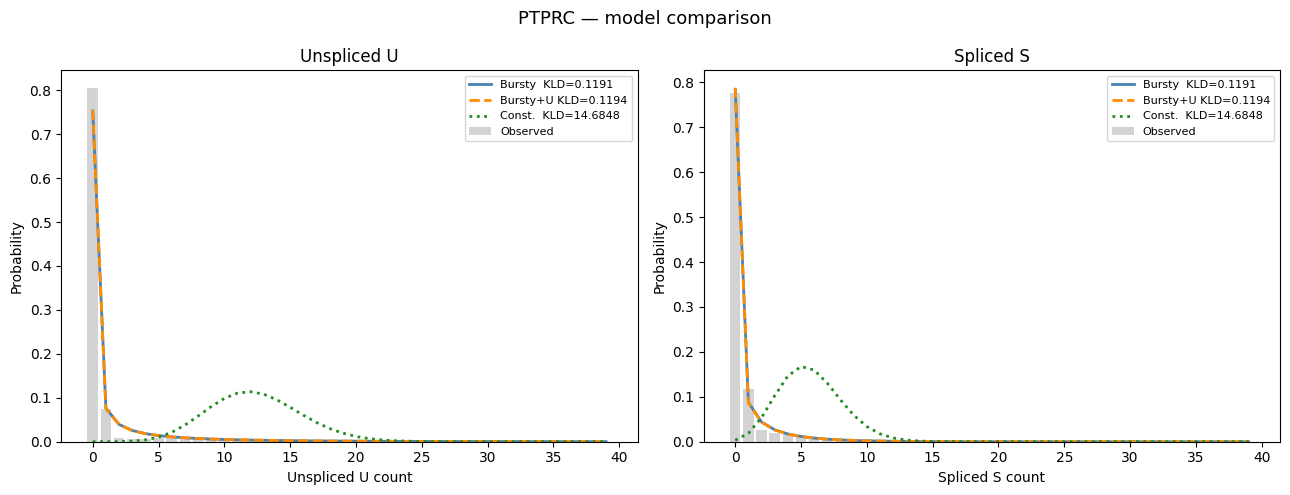

In [19]:
# ── 7.5  Visual comparison ───────────────────────────────────────────────────

# Empirical marginals
obs_u = np.zeros(M[0]); obs_s = np.zeros(M[1])
for (cu, cs), f in zip(coords, freqs):
    if int(cu) < M[0]: obs_u[int(cu)] += f
    if int(cs) < M[1]: obs_s[int(cs)] += f

# Compute fitted PSS for each model
pss_bursty = m_ref_bursty.eval_model_pss(p_bursty_opt, M)
pss_udeg   = m_udeg.eval_model_pss(p_udeg_opt, M)
pss_con    = m_con.eval_model_pss(p_con_opt, M)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, obs, axis, label in [
    (axes[0], obs_u, 1, 'Unspliced U'),
    (axes[1], obs_s, 0, 'Spliced S'),
]:
    ax.bar(range(len(obs)), obs, color='lightgrey', label='Observed', zorder=1)
    for pss, name, ls, col in [
        (pss_bursty, f'Bursty  KLD={kld_bursty:.4f}',  '-',  'steelblue'),
        (pss_udeg,   f'Bursty+U KLD={kld_udeg:.4f}', '--', 'darkorange'),
        (pss_con,    f'Const.  KLD={kld_con:.4f}',    ':',  'forestgreen'),
    ]:
        marg = pss.sum(axis=axis)
        ax.plot(marg, lw=2, ls=ls, color=col, label=name)
    ax.set_xlabel(f'{label} count'); ax.set_ylabel('Probability')
    ax.set_title(label); ax.legend(fontsize=8)

fig.suptitle(f'{gene} — model comparison', fontsize=13)
plt.tight_layout(); plt.show()

The model with the **lowest KLD** is the best fit to this gene's data.

The Constitutive model (no bursting) fits poorly — as expected for a gene with
variance well above the mean.  The Bursty and Bursty+Udecay models are similar;
the AIC penalising the extra parameter in Bursty+Udecay can be used for formal selection.

In [20]:
# ── AIC (lower is better) ────────────────────────────────────────────────────
n_cells = proc_adata.n_obs
print('AIC = 2k + 2·n_cells·KLD  (proportional to negative log-likelihood)\n')
for name, kld, n_p, _ in rows:
    aic = 2 * n_p + 2 * n_cells * kld
    print(f'  {name:<25}  n_params={n_p}  KLD={kld:.5f}  AIC={aic:.1f}')

AIC = 2k + 2·n_cells·KLD  (proportional to negative log-likelihood)

  Bursty (built-in)          n_params=3  KLD=0.11910  AIC=15724.0
  Bursty + U decay           n_params=4  KLD=0.11940  AIC=15765.5
  Constitutive               n_params=3  KLD=14.68480  AIC=1938047.0
